MODELO RANDOM FOREST

In [6]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import missingno as msno

# Expresiones regulares
import gdown
import re
import warnings
warnings.filterwarnings('ignore')

import os

# Preprocesamiento de datos y ML
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import ADASYN
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline


# Evaluacion
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [8]:
path = 'FINAL/bank-additional_bank-additional-full.csv'
delimiter = ';'

data = pd.read_csv(path, delimiter=delimiter)

# Mostramos las primeras filas del DataFrame para verificar la carga de datos
data.head() 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


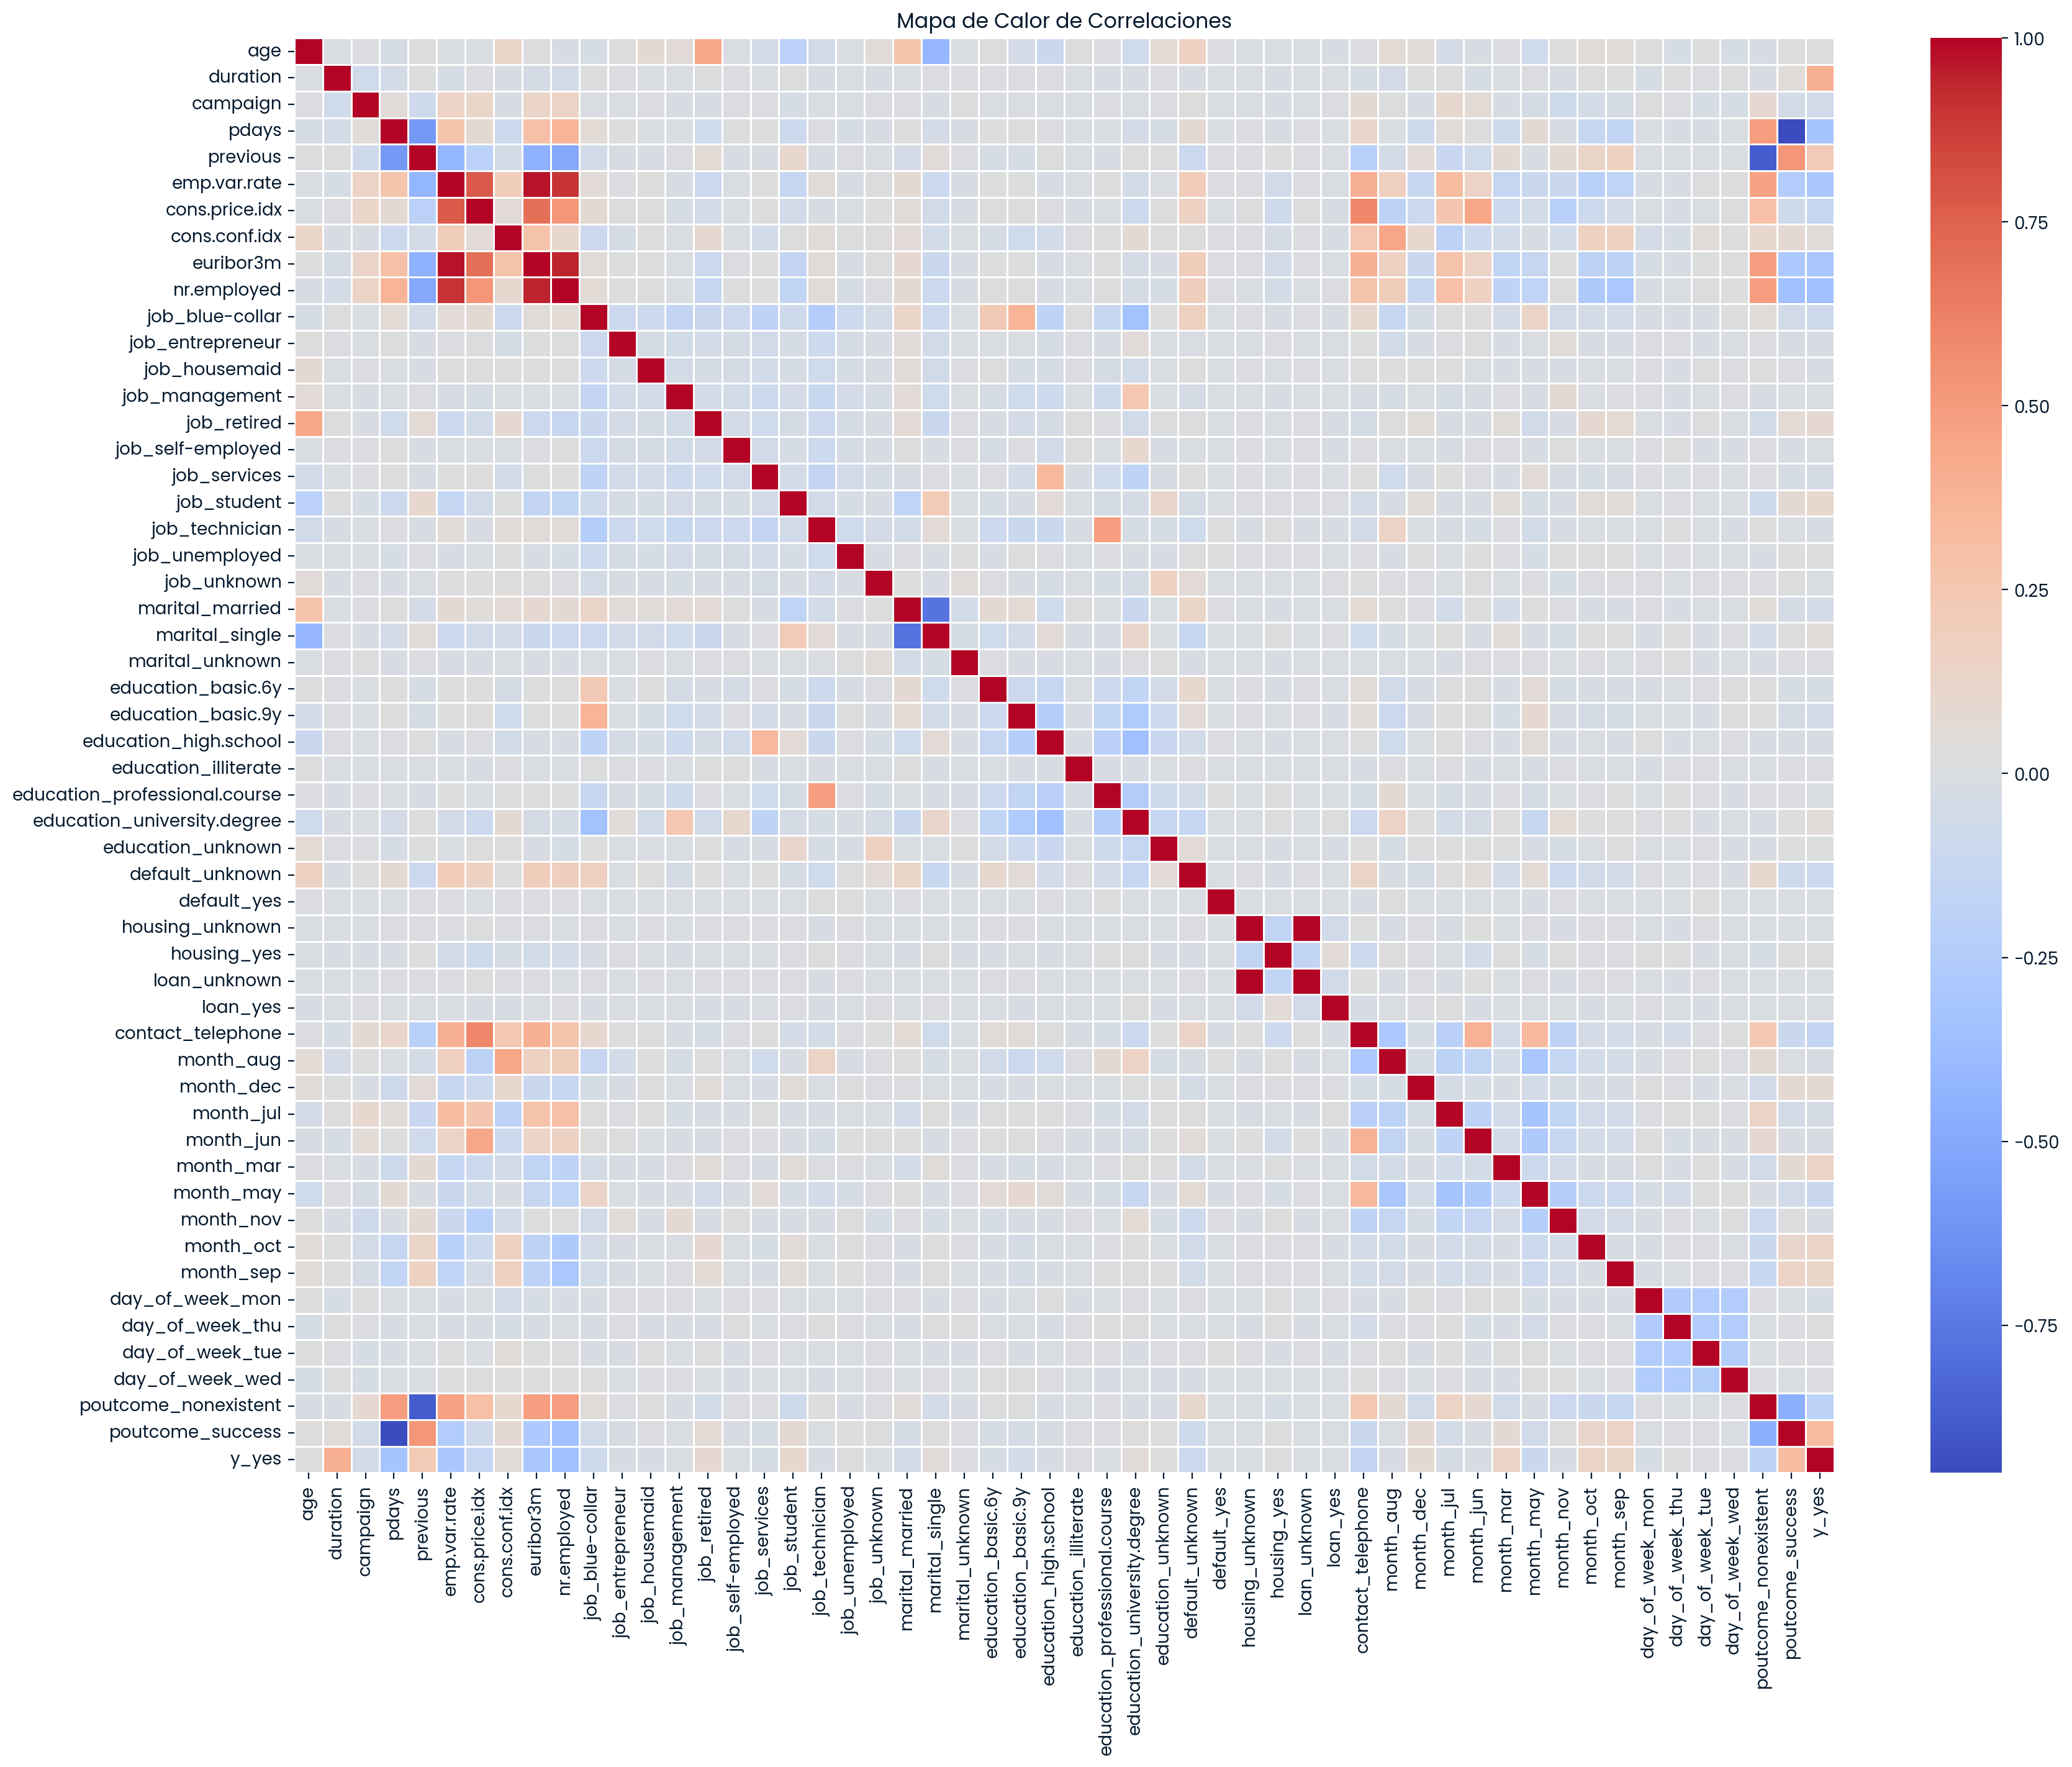

In [9]:
# Convertimos todas las variables categóricas a variables dummy, sin cambiar 'y'
data_dum = pd.get_dummies(data, drop_first=True)

# Calculamos la matriz de correlación
corr_matrix = data_dum.corr()

# Grafico del mapa de calor
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones")
plt.show()


Variables más correlacionadas:

duration (0.41): Relación positiva moderada con la variable objetivo y. Podría ser una variable clave para predecir si un cliente aceptará el depósito.
poutcome_success (0.32): Relación moderada, lo que indica que el resultado previo del contacto tiene algo de influencia sobre la aceptación.
previous (0.23): Una correlación positiva moderada, lo que sugiere que los clientes con más interacciones previas podrían estar más dispuestos a aceptar el depósito.
Variables ligeramente correlacionadas:

month_mar (0.14), month_oct (0.14), month_sep (0.13): Los meses en los que se realizan las campañas de contacto tienen una correlación positiva baja, lo que sugiere que el mes podría tener alguna influencia, pero no es un factor principal.
job_student, job_retired (0.09): Las personas que son estudiantes o jubilados tienen una correlación baja con la aceptación, lo que sugiere que su probabilidad de aceptar es relativamente baja, pero no es completamente irrelevante.
Variables con baja o casi nula correlación:

Varias variables tienen correlaciones cercanas a 0 (como education_unknown, job_unemployed, day_of_week_thu, housing_yes, entre otras). Estas variables podrían no ser útiles para el modelo, ya que no aportan información significativa para predecir si un cliente aceptará el depósito.

Variables menos correlacionadas:

emp.var.rate (-0.30), euribor3m (-0.31), pdays (-0.32): Tienen correlaciones negativas moderadas, lo que sugiere que a medida que estas variables aumentan, la probabilidad de que el cliente acepte el depósito disminuye.
nr.employed (-0.35): La correlación negativa más fuerte con y. Esto podría indicar que más empleados en una empresa o región podría estar asociado con una menor probabilidad de aceptación del depósito.

In [10]:
# Variables de entrada
target = 'y'

# Variables categóricas
categorical_vars = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Variables numéricas (agregamos 'nr.employed')
numeric_vars = ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m', 'emp.var.rate',
                'cons.price.idx', 'cons.conf.idx', 'nr.employed']

# Revisamos las variables antes de usarlas en el modelo
print("Variables categóricas:", categorical_vars)
print("Variables numéricas:", numeric_vars)


Variables categóricas: ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']
Variables numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']


In [11]:
# Seleccionamos variables de entrada y target
X = data[categorical_vars + numeric_vars]
y = data[target].map({'yes': 1, 'no': 0})  # Convertimos 'yes/no' a 1/0

# Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Vemos la distribución original de la clase en el entrenamiento
print("Distribución original en entrenamiento:", Counter(y_train))

Distribución original en entrenamiento: Counter({0: 25583, 1: 3248})


In [12]:
# Creamos el objeto OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Aplicamos el OneHotEncoder sobre las características categóricas
X_train_encoded = encoder.fit_transform(X_train)

# Creamos el objeto SMOTE con sampling_strategy=1.0 (balancea a 50/50)
smote = SMOTE(sampling_strategy=0.7, random_state=42)

# Aplicamos SMOTE sobre el conjunto de entrenamiento
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_encoded, y_train)

# Veemos la nueva distribución en el conjunto de entrenamiento
print("Distribución balanceada en entrenamiento:", Counter(y_train_balanced))

Distribución balanceada en entrenamiento: Counter({0: 25583, 1: 17908})


In [13]:
# Preprocesamiento: imputamos, escalamos y codificamos
preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='mean')),
             ('scaler', StandardScaler())
         ]),
         numeric_vars),
        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('encoder', OneHotEncoder(drop='first'))
         ]),
         categorical_vars)
    ]
)

In [14]:
# Creamos la pipeline que incluye SMOTE y Random Forest

pipeline = ImbPipeline([  # Use ImbPipeline instead of Pipeline
    ('preprocessor', preprocessor),
    ('smote_tomek', SMOTETomek(sampling_strategy=0.5, random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',  # Peso ajustado para la clase "YES"
        max_depth=10,
        min_samples_split=10,
        random_state=42
    ))
])

In [15]:
# Entrenamos el modelo con la pipeline
pipeline.fit(X_train, y_train)

# Realizamos predicciones en el conjunto de prueba con un umbral ajustado
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Evaluamos el modelo
print("Random Forest con SMOTE - Classification Report:")
print(classification_report(y_test, y_pred))
print("Random Forest con SMOTE - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest con SMOTE - Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.92     10965
           1       0.47      0.91      0.62      1392

    accuracy                           0.87     12357
   macro avg       0.73      0.89      0.77     12357
weighted avg       0.93      0.87      0.89     12357

Random Forest con SMOTE - Confusion Matrix:
[[9540 1425]
 [ 132 1260]]
